In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

print("Images loaded successfully.")

Images loaded successfully.


In [3]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

print("Data concatenated successfully.")

Data concatenated successfully.


In [4]:
All_data_normalized = All_data / 255.0

print("Data normalized successfully.")

Data normalized successfully.


In [5]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

print("Labels encoded and data split successfully.")

Labels encoded and data split successfully.


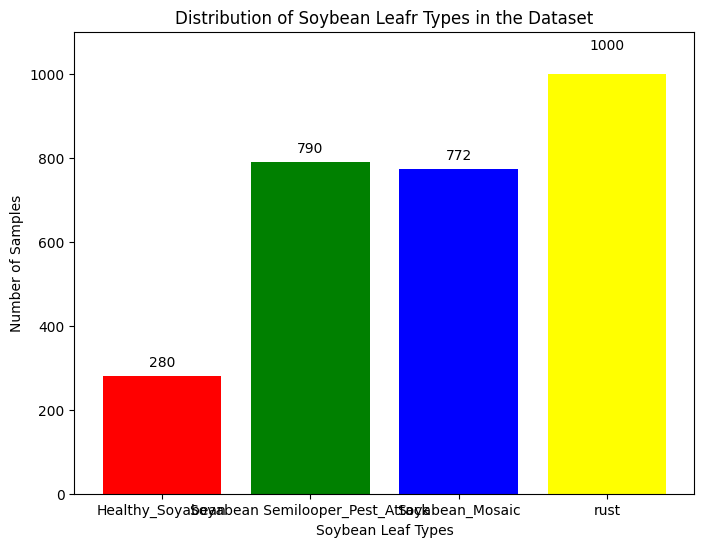

Data distribution plotted successfully.


In [6]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue', 'yellow'])
plt.xlabel('Soybean Leaf Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Soybean Leafr Types in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

print("Data distribution plotted successfully.")

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

def build_simple_fpn_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (your 3 conv blocks)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)  # C3 base
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(c3)    # C4 base
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x32

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(c4)    # C5 base
    c5 = layers.MaxPooling2D(2)(x)   #  8x8x64

    # Lateral 1x1 to unify channels
    l3 = layers.Conv2D(fpn_channels, 1, padding='same')(c3)  # 32x32xF
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)  # 16x16xF
    l5 = layers.Conv2D(fpn_channels, 1, padding='same')(c5)  #  8x8xF

    # Top-down pathway (nearest upsample + add)
    p5 = l5
    p4 = layers.Add()([l4, layers.UpSampling2D(2)(p5)])      # 8->16
    p3 = layers.Add()([l3, layers.UpSampling2D(2)(p4)])      # 16->32

    # Light 3x3 refinement (optional but common in FPN)
    p3 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p3)
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p4)
    p5 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p5)

    # Convert to one vector for SVM: GAP each level and concat
    g3 = layers.GlobalAveragePooling2D()(p3)   # -> (F,)
    g4 = layers.GlobalAveragePooling2D()(p4)   # -> (F,)
    g5 = layers.GlobalAveragePooling2D()(p5)   # -> (F,)
    feat_vec = layers.Concatenate(name="fpn_feat")([g3, g4, g5])  # -> (3F,)

    return models.Model(x_in, feat_vec, name="simple_fpn_feature_extractor")

cnn_model = build_simple_fpn_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model.summary()

Model: "simple_fpn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 64, 64,    │        504 │ input_layer_4[0]… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 32, 32,    │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32,    │      5,216 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ conv2d_37[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_13… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 8, 8, 64)  │          0 │ conv2d_38[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 8, 8, 64)  │      4,160 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_13… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 16, 16,    │          0 │ conv2d_41[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 16, 16,    │          0 │ conv2d_40[0][0],  │
│                     │ 64)               │            │ up_sampling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │      1,216 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 32, 32,    │          0 │ add_8[0][0]       │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 32, 32,    │          0 │ conv2d_39[0][0],  │
│                     │ 64)               │            │ up_sampling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_9[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 16, 16,    │     36,928 │ add_8[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 8, 8, 64)  │     36,928 │ conv2d_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 142,488 (556.59 KB)

 Trainable params: 142,488 (556.59 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Feature extraction (same usage pattern as your code)
train_features = cnn_model.predict(train_data, batch_size=64, verbose=0)
test_features  = cnn_model.predict(test_data,  batch_size=64, verbose=0)

# (Optional) L2 normalization helps SVMs
def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features = l2_normalize(train_features)
test_features  = l2_normalize(test_features)

# If you still want to "flatten" like before, it's already 2D (N, 3*fpn_channels).
# But this keeps compatibility with your original lines:
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
test_features_flattened  = np.reshape(test_features,  (test_features.shape[0], -1))

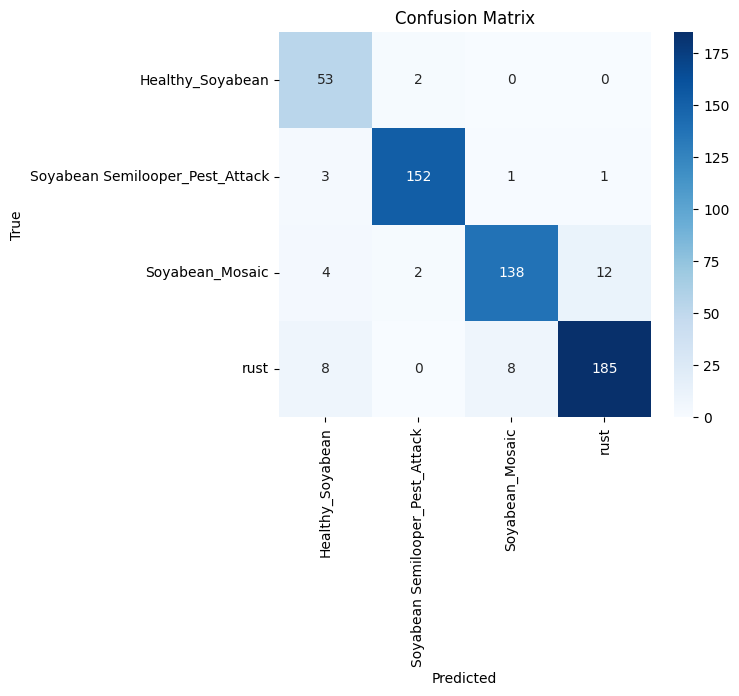

Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean       0.78      0.96      0.86        55
Soyabean Semilooper_Pest_Attack       0.97      0.97      0.97       157
                Soyabean_Mosaic       0.94      0.88      0.91       156
                           rust       0.93      0.92      0.93       201

                       accuracy                           0.93       569
                      macro avg       0.91      0.93      0.92       569
                   weighted avg       0.93      0.93      0.93       569



In [25]:
from sklearn.svm import SVC
# 🧠 Step 1: Fit final model
final_model = SVC(C=25, kernel='rbf', gamma=1, probability=True,  class_weight="balanced", random_state=42)
final_model.fit(train_features_flattened, train_labels)

# 🚀 Step 2: Predictions
pred_labels = final_model.predict(test_features_flattened)
pred_probs = final_model.predict_proba(test_features_flattened)

# 📊 Step 3: Confusion Matrix
cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 🧾 Step 4: Classification Report
print("Classification Report:\n", classification_report(test_labels, pred_labels, target_names=label_encoder.classes_))

In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==========================================================
# Split TRAIN into Train + Validation
# ==========================================================
X_train, X_val, y_train, y_val = train_test_split(
    train_features_flattened,
    train_labels,
    test_size=0.20,          # 20% of training -> validation
    stratify=train_labels,
    random_state=42
)

best_acc = 0
best_kernel = None
best_C = None

# ==========================================================
# Hyperparameter Search
# ==========================================================
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:

    print(f"\nKernel: {kernel}")

    c_value = 0.1

    while c_value <= 50.0:

        svm_model = SVC(
            kernel=kernel,
            C=c_value,
            class_weight='balanced',
            random_state=42
        )

        svm_model.fit(X_train, y_train)

        val_pred = svm_model.predict(X_val)

        val_acc = accuracy_score(y_val, val_pred)

        print(f"C = {c_value:.1f} | Validation Accuracy = {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_kernel = kernel
            best_C = c_value

        c_value += 0.5

print("\n==============================")
print("Best Hyperparameters")
print("==============================")
print(f"Kernel : {best_kernel}")
print(f"C      : {best_C}")
print(f"Validation Accuracy : {best_acc:.4f}")


Kernel: linear
C = 0.1 | Validation Accuracy = 0.6505
C = 0.6 | Validation Accuracy = 0.7846
C = 1.1 | Validation Accuracy = 0.7868
C = 1.6 | Validation Accuracy = 0.8044
C = 2.1 | Validation Accuracy = 0.8286
C = 2.6 | Validation Accuracy = 0.8440
C = 3.1 | Validation Accuracy = 0.8527
C = 3.6 | Validation Accuracy = 0.8615
C = 4.1 | Validation Accuracy = 0.8681
C = 4.6 | Validation Accuracy = 0.8703
C = 5.1 | Validation Accuracy = 0.8725
C = 5.6 | Validation Accuracy = 0.8725
C = 6.1 | Validation Accuracy = 0.8747
C = 6.6 | Validation Accuracy = 0.8747
C = 7.1 | Validation Accuracy = 0.8791
C = 7.6 | Validation Accuracy = 0.8791
C = 8.1 | Validation Accuracy = 0.8813
C = 8.6 | Validation Accuracy = 0.8835
C = 9.1 | Validation Accuracy = 0.8835
C = 9.6 | Validation Accuracy = 0.8879
C = 10.1 | Validation Accuracy = 0.8879
C = 10.6 | Validation Accuracy = 0.8923
C = 11.1 | Validation Accuracy = 0.8923
C = 11.6 | Validation Accuracy = 0.8923
C = 12.1 | Validation Accuracy = 0.8923
C = 

In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ==========================================================
# Split Training Data into Train + Validation
# ==========================================================
X_train, X_val, y_train, y_val = train_test_split(
    train_features_flattened,
    train_labels,
    test_size=0.20,
    stratify=train_labels,
    random_state=42
)

# ==========================================================
# Fixed Hyperparameters
# ==========================================================
kernel = 'poly'
c_value = 39.6

gamma_values = [
    'scale',
    'auto',
    0.001,
    0.01,
    0.1,
    1,
    2,
    3,
    4,
    5,
    10
]

# ==========================================================
# Find Best Gamma Using Validation Set
# ==========================================================
best_gamma = None
best_val_acc = 0

for gamma in gamma_values:

    model = SVC(
        kernel=kernel,
        C=c_value,
        gamma=gamma,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    val_acc = accuracy_score(y_val, val_pred)

    print(f"Gamma = {gamma} | Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_gamma = gamma

print("\n==============================")
print("Best Gamma Found")
print("==============================")
print(f"Gamma = {best_gamma}")
print(f"Validation Accuracy = {best_val_acc:.4f}")

# ==========================================================
# Retrain on FULL Training Data
# ==========================================================
final_model = SVC(
    kernel=kernel,
    C=c_value,
    gamma=best_gamma,
    class_weight='balanced',
    random_state=42
)

final_model.fit(train_features_flattened, train_labels)

# ==========================================================
# Final Evaluation on Test Set (ONLY ONCE)
# ==========================================================
test_predictions = final_model.predict(test_features_flattened)

test_acc = accuracy_score(test_labels, test_predictions)

print("\n==============================")
print("Final Test Results")
print("==============================")
print(f"Test Accuracy = {test_acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=label_encoder.classes_
    )
)

Gamma = scale | Validation Accuracy = 0.9714
Gamma = auto | Validation Accuracy = 0.3516
Gamma = 0.001 | Validation Accuracy = 0.3516
Gamma = 0.01 | Validation Accuracy = 0.3516
Gamma = 0.1 | Validation Accuracy = 0.6308
Gamma = 1 | Validation Accuracy = 0.9495
Gamma = 2 | Validation Accuracy = 0.9714
Gamma = 3 | Validation Accuracy = 0.9802
Gamma = 4 | Validation Accuracy = 0.9802
Gamma = 5 | Validation Accuracy = 0.9846
Gamma = 10 | Validation Accuracy = 0.9802

Best Gamma Found
Gamma = 5
Validation Accuracy = 0.9846

Final Test Results
Test Accuracy = 0.9701

Classification Report:
                                 precision    recall  f1-score   support

               Healthy_Soyabean       0.96      1.00      0.98        55
Soyabean Semilooper_Pest_Attack       0.98      0.98      0.98       157
                Soyabean_Mosaic       0.97      0.94      0.95       156
                           rust       0.96      0.98      0.97       201

                       accuracy          

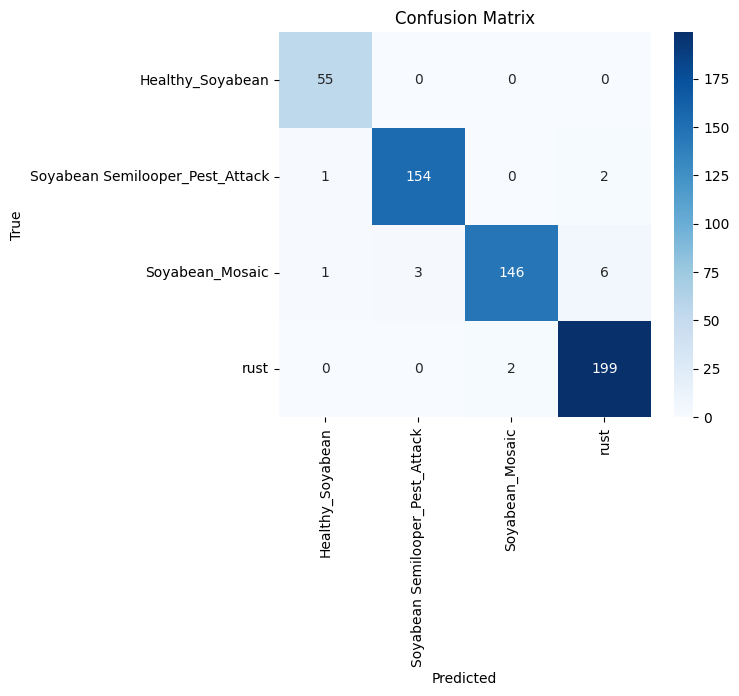

Classification Report:
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9649    1.0000    0.9821        55
Soyabean Semilooper_Pest_Attack     0.9809    0.9809    0.9809       157
                Soyabean_Mosaic     0.9865    0.9359    0.9605       156
                           rust     0.9614    0.9900    0.9755       201

                       accuracy                         0.9736       569
                      macro avg     0.9734    0.9767    0.9748       569
                   weighted avg     0.9740    0.9736    0.9735       569



In [28]:
# 🧠 Step 1: Fit final model
final_model = SVC(C=39.6, kernel='poly', gamma=5, probability=True, random_state=42)
final_model.fit(train_features_flattened, train_labels)

# 🚀 Step 2: Predictions
pred_labels = final_model.predict(test_features_flattened)
pred_probs = final_model.predict_proba(test_features_flattened)

# 📊 Step 3: Confusion Matrix
cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 🧾 Step 4: Classification Report
print("Classification Report:\n", classification_report(test_labels, pred_labels, target_names=label_encoder.classes_,digits=4))

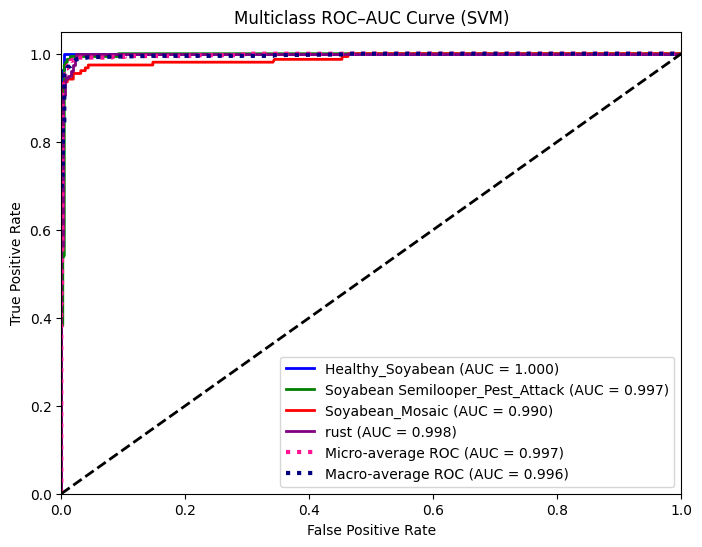

In [34]:
# 🔧 Binarize the labels for multiclass ROC
y_test_bin = label_binarize(test_labels, classes=range(num_classes))

y_pred_proba = pred_probs  

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# 📈 Plot ROC Curve
plt.figure(figsize=(8,6))
colors = ["blue", "green", "red", "purple"]  # one per class
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

# Add micro/macro
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")

plt.plot([0,1], [0,1], "k--", lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (SVM)")
plt.legend(loc="lower right")
plt.show()